# Initialization

In [ ]:
from gradient_estimation_helpers import *

# Fast Quantum Algorithm for Numerical Gradient Estimation
> Given a scalar function of $d$ dimensions, $f(x_1, \ldots, x_d)$, computing its gradient at a specific point is often essential.
>
> On a classical computer, this requires at least $d+1$ queries to $f$.
>
> This notebook presents a quantum algorithm that computes the gradient with a single query, based on the paper by S. P. Jordan [\[1\]](#original_paper).
> 
> This represents a dramatic speedup for high-dimensional functions, where function evaluation is typically the dominant computational cost.
>
> - **Input:** A black-box function $f$ of $d$ dimensions.
> - **Promise:** The function is smooth and has bounded gradient: $|\nabla f|<\nabla f_{\text{max}}$.
> - **Output:** The gradient $\nabla f$ at the origin with $n$ bits of precision, encoded on a quantum register.
> 
> **Complexity:** In black-box query complexity, the classical algorithm requires at least $d+1$ queries to $f$, while the quantum algorithm requires only one.
>
> ---
>
> **Keywords:** Foundational quantum algorithms, Gradient, Function evaluation, Oracle problem, Quantum Fourier Transform (QFT)


The core idea is to encode the function into the phase of a superposition state, then apply an inverse QFT to extract the gradient as a measurable outcome.

We demonstrate this step by step—first with a simplified version to build intuition, then with refinements for the complete algorithm.

![Quantum Circuit](quantum_circuit_2.png)

# 1. Introduction

## 1.1. Simplified explanation of the algorithm
The algorithm has two main steps:
1. Encode the function into the phase of a quantum superposition
2. Extract the gradient as a measurable state

**In detail:**

1. We define an interval $l$ with $N$ points around the origin where we estimate the gradient, establishing a resolution $\mathrm{dx}=l/N$.

For each dimension ($x_i$), we create the superposition $|\delta_i\rangle=|-l\rangle+|-l+\mathrm{dx}\rangle+|-l+2\mathrm{dx}\rangle\cdots|l-\mathrm{dx}\rangle$ using Hadamard gates on $|0\rangle^{\otimes n}$.

*The actual encoding on qubits is discussed later.*

For simplicity, we consider a single dimension. For $d > 1$, the state $|\delta\rangle$ is a tensor product over all dimensions:
$$|\delta\rangle=\prod_i|\delta_i\rangle$$

2. Using a phase oracle or the phase kickback technique, we encode the function as phases:
$$e^{i\cdot2\pi f(-l)}|-l\rangle + e^{i\cdot2\pi f(-l+\mathrm{dx})}|-l+\mathrm{dx}\rangle + e^{i\cdot2\pi f(-l+2\mathrm{dx})}|-l+2\mathrm{dx}\rangle \cdots e^{i\cdot2\pi f(l-\mathrm{dx})}|l-\mathrm{dx}\rangle$$
![](step_2.png)

3. For a sufficiently small interval, we approximate $f(x)\approx f(0)+x\cdot f'(0)$, allowing us to factor the state:
$$\begin{aligned}
& e^{i\cdot2\pi f(0)}\left(e^{i\cdot2\pi (-l)\cdot f'(0)}\lvert-l\rangle + e^{i\cdot2\pi (-l+\mathrm{dx})f'(0)}\lvert-l+\mathrm{dx}\rangle + e^{i\cdot2\pi (-l+2\mathrm{dx})f'(0)}\lvert-l+2\mathrm{dx}\rangle \cdots e^{i\cdot2\pi (l-\mathrm{dx})f'(0)}\lvert l-\mathrm{dx}\rangle\right) \\
&= e^{i\cdot2\pi f(0)}\sum_{-l}^{l-\mathrm{dx}} e^{i\cdot2\pi jf'(0)}|j\rangle
\end{aligned}$$
![](step_3.png)

4. This state is exactly the QFT of the computational basis state $|f'(0)\rangle$. Applying the inverse QFT yields:
$$|f'(0)\rangle$$

5. Measure the register to obtain $f'(0)$ (or $\nabla f$ for multi-dimensional functions).

## 1.2. Full explanation of the algorithm
The simplified explanation captures the key idea but omits two important details: handling negative values and fractional representation.

When estimating the gradient, we analyze an interval $l$ around the origin.

The state $|\delta_i\rangle$ represents $N$ equally spaced points in this interval, normalized as:
$$ x=\frac{l}{N}\delta $$

With signed $\delta$ ranging from $-N/2$ to $N/2-1$: $\delta=-N/2$ is the leftmost point ($-l/2$), $\delta=0$ is the origin, and $\delta=N/2-1$ is the rightmost point ($l/2$)*.

We also normalize the output. Assuming the gradient is bounded between $-m/2$ and $m/2$, we represent those values using the $N$ states:
$$ \nabla f=\frac{m}{N}\delta_{measured} $$

When applying the algorithm, we choose $l$ and $m$ based on prior knowledge of $f(x)$. The value $N$ determines the final resolution.

$l$ must be small enough to keep the function approximately linear, and $m$ must exceed the maximum expected gradient magnitude while maintaining sufficient resolution.

Using these two normalizations, we modify the algorithm:
1. In step 2, instead of applying $f(\delta)$, we apply $\frac{N}{ml}f\left(\frac{l}{N}\delta\right)$.
2. In step 5, the signed measurement directly gives $\frac{N}{m}\nabla f$, so $\nabla f = \frac{m}{N}\delta_{measured}$.

Using a signed register means the measured $\delta_{measured}$ is already the correct signed value with no further adjustment needed.

\* The rightmost point is actually $l/2-l/N$ rather than $l/2$, because the center is at the origin and $N$ must be even. However, this distinction does not affect the conceptual understanding.

## 1.3. Parameter Selection
We need to select appropriate values for $l$, $m$, and $N$. We use the following notation: 
* $\nabla f_{\text{max}}$ — bound on the gradient magnitude: $|\nabla f|<\nabla f_{\text{max}}$
* $\epsilon$ — desired accuracy: $|\nabla f_{\text{est}}-\nabla f| < \epsilon$
* $d$ — dimensionality of $f$
* $D_2$ — bound on the second derivative of $f$ near the origin

### Selecting $l$
Choose $l$ to ensure the function remains approximately linear. Similar to classical numerical differentiation, this interval must be sufficiently small.

To keep gradient variation within accuracy $\epsilon$, we require $\nabla f_{\text{max}} - \nabla f_{\text{min}} \le \epsilon$.

For a single dimension, the second derivative is approximately $f''(x) \approx (\nabla f_{\text{max}} - \nabla f_{\text{min}}) / l$. This gives $l < \frac{\epsilon}{|f''(x)|}$.

Using $D_2$ as the second derivative bound, we get $l < \frac{\epsilon}{D_2}$.

In multiple dimensions, we sum deviations as root-mean-square across all $d$ dimensions, introducing a factor of $1/\sqrt{d}$.

To improve this bound, we scale by the uniform distribution variance, $\frac{1}{12}$.

The final bound for $l$ is: 
$$l\leq\frac{2\sqrt{3}\epsilon}{D_2\sqrt{d}}$$

For a one-dimensional quadratic function $f(x)=ax^2+bx+c$, we need $l$ smaller than $\frac{\sqrt{12}\epsilon}{2a}$.

Furthermore, in order to minimize the number of bits of precision to which $f$ must be evaluated, $l$ should be chosen as large as possible, subject to the constraint above. So $l$ should be chosen tightly.

See Jordan's paper [\[1\]](#original_paper) for a full derivation.

### Selecting $m$
The parameter $m$ bounds the gradient magnitude. Since the gradient is signed, we need $m \ge 2\nabla f_{\text{max}}$.

The resolution of the result is $\frac{m}{N}$. For a given register size and accuracy $\epsilon$, the upper bound is $m \le 2N\epsilon$.

### Selecting $n$
$N=2^n$ defines the result resolution. The step size between possible outcomes is $\frac{m}{N}$.

To achieve accuracy $\epsilon$, we need $N\geq\frac{m}{2\epsilon}$.

Assuming tight $m$ selection, this gives a lower bound for the number of qubits:
$$n\geq\log_2\left(\frac{\nabla f_{\text{max}}}{\epsilon}\right)$$

### Summary
Given $\nabla f_{\text{max}}$ and desired accuracy $\epsilon$, select parameters as:


| Parameter | Role | Constraint |
|---|---|---|
| $l$ | Sampling interval | $l \leq \frac{2\sqrt{3}\epsilon}{D_2\sqrt{d}}$ — keeps $f$ approximately linear |
| $m$ | Gradient range | $2\nabla f_{\max} \leq m \leq 2N\epsilon$ |
| $n$ | Qubits / resolution | $n \geq \log_2(\nabla f_{\max} / \epsilon)$ |

## 1.4. Outline
This notebook covers:
1. Theoretical foundation and parameter selection
2. Implementation
    - Phase state preparation (phase kickback and direct methods)
    - Inverse QFT for gradient extraction
    - Examples with linear and non-linear functions
3. Performance analysis
4. Multi-dimensional examples ($d > 1$)

# 2. Implementation

## 2.1. State Preparation

### 2.1.1. Phase Kickback

The first step is to prepare the state:
$$\sum_{\delta}e^{i2\pi\frac{N}{ml}f(\frac{l}{N}\delta)}|\delta\rangle$$

The paper assumes an oracle $|x\rangle \rightarrow |f(x)\rangle$, which we use with the phase kickback technique to create this state.

The next example demonstrates how this works.

The phase kickback has three main steps:
1. Apply Hadamard gates on $|\delta\rangle$ to create a superposition of all sample points
2. Initialize the ancilla to $|1111...1\rangle$ (in binary) and apply QFT
3. Add $f(\delta)$ to the ancilla; the function value is "kicked back" as a phase

See the [appendix](#appendix-1---phase-kickback) for details.

In [ ]:
# Set the default values:
# l = 0.5, m = 2, n = 3, n0 = 3
p = params()

# Set the function we want to calculate the gradient of:
# f(x) = 0.5*x + 0.25
# Gradient: f'(0) = 0.5
p.set_function(p.linear, (0.5, 0.25))

# Unpack the parameters to global variables for easier use
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]], ancilla: Output[QNum[n0, SIGNED, n0]]):
    # 1. State preparation

    # 1.1. Set the coordinates state - Apply Hadamard gate on the coordinates register
    allocate(n, x)
    hadamard_transform(x)

    # 1.2. Set the ancilla state - Apply QFT to |1111...1> state
    prepare_basis_state([True] * n0, ancilla)
    qft(ancilla)

    # 1.3. Apply the function f on the ancilla, to create the phase kickback
    # Calculate the normalized f and add it to the ancilla
    val = f_normalized(x)
    inplace_add(val, ancilla)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))


# Run using a statevector simulator
qprog = synthesize(main)
# show(qprog) # Uncomment to see the circuit
print("Circuit Width:", qprog.data.width)
print("Circuit Depth:", qprog.transpiled_circuit.depth)
print("Gate Counts:", qprog.transpiled_circuit.count_ops)

sv = calculate_state_vector(qprog)
df = sv[sv.ancilla == 0]
df.sort_values(by="x", inplace=True)
df

# From now on, we will use the shortcut function:
# df = run_statevector_simulation(main, print_circuit_info=True, filter_ancilla=True)

Submitting job to simulator


Circuit Width: 7
Circuit Depth: 30
Gate Counts: {'u': 25, 'cx': 19}


Job: https://platform.classiq.io/jobs/70ff34e5-b32e-4658-875a-73457dbeccd0
/var/folders/3m/h6bttp2n307cd0qt29h_mc440000gn/T/ipykernel_97551/4002175823.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by="x", inplace=True)


,x,ancilla,amplitude,magnitude,phase,probability,bitstring
63,-4,0.0,0.088388+0.088388j,0.12,0.25π,0.015625,0000100
40,-3,0.0,-0.088388+0.088388j,0.12,0.75π,0.015625,0000101
61,-2,0.0,-0.088388-0.088388j,0.12,-0.75π,0.015625,0000110
41,-1,0.0,0.088388-0.088388j,0.12,-0.25π,0.015625,0000111
60,0,0.0,0.088388+0.088388j,0.12,0.25π,0.015625,0000000
39,1,0.0,-0.088388+0.088388j,0.12,0.75π,0.015625,0000001
53,2,0.0,-0.088388-0.088388j,0.12,-0.75π,0.015625,0000010
30,3,0.0,0.088388-0.088388j,0.12,-0.25π,0.015625,0000011


Let's examine the phase compared to the classical function value:

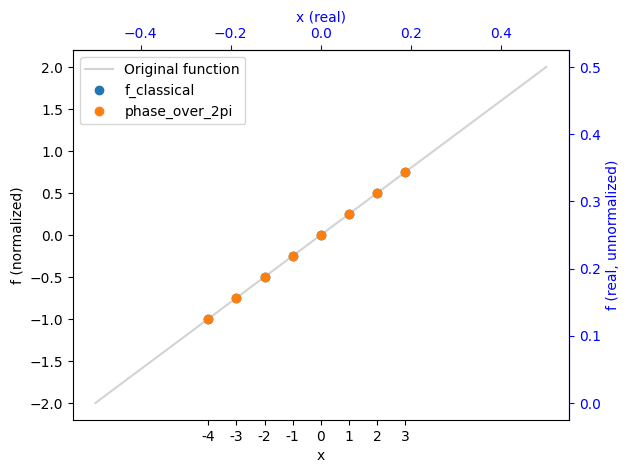

,f_classical,phase_over_2pi
x,,
-4,-1.00,-1.00
-3,-0.75,-0.75
-2,-0.50,-0.50
-1,-0.25,-0.25
0,0.00,0.00
1,0.25,0.25
2,0.50,0.50
3,0.75,0.75


In [5]:
# Shift the classical function to match the quantum convention
f_classical = f_normalized(df["x"]) - f_normalized(0)
# Create a simplified dataframe with the relevant information, and sort it by the x values.
phases = np.angle(df["amplitude"]).astype(float)
phases_over_2pi = phases / (2 * np.pi)
simplified_df = pd.DataFrame(
    {"f_classical": f_classical, "phase_over_2pi": phases_over_2pi.round(5)}
)
simplified_df.index = df["x"]
simplified_df.sort_index(inplace=True)
# Unwrap the phase
simplified_df["phase_over_2pi"] = np.unwrap(simplified_df["phase_over_2pi"], period=1)
# Get rid of the global phase
simplified_df["phase_over_2pi"] -= simplified_df["phase_over_2pi"].iloc[N // 2]
simplified_df["f_classical"] -= simplified_df["f_classical"].iloc[N // 2]

# Plot the results
plt.figure()
plot_classical()
simplified_df.plot(style="o", ax=plt.gca())
plt.legend()
plt.show()

# Show the results as a dataframe
simplified_df

The graph shows the original function (gray), classical values (blue), and quantum phase at sample points (orange). Results are displayed in both normalized coordinates (black axes) and original values (blue axes).

Here is the complete code to reproduce the graph:

Circuit Width: 8
Circuit Depth: 42
Gate Counts: {'u': 31, 'cx': 27}


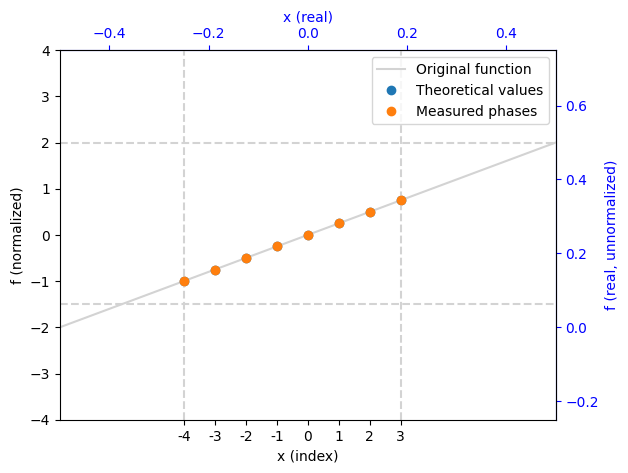

In [ ]:
p = params()
# f(x) = 0.5*x + 0.25
# Gradient: f'(0) = 0.5
p.set_function(p.linear, (0.5, 0.25))
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]], ancilla: Output[QNum[n0, SIGNED, n0]]):
    # 1. State preparation

    # 1.1. Set the coordinates state - Apply Hadamard gate on the coordinates register
    allocate(n, x)
    hadamard_transform(x)

    # 1.2. Set the ancilla state - Apply QFT to |1111...1> state
    prepare_basis_state([True] * n0, ancilla)
    qft(ancilla)

    # 1.3. Apply the function f on the ancilla, to create the phase kickback
    # Calculate the normalized f and add it to the ancilla
    val = f_normalized(x)
    inplace_add(val, ancilla)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))


df = run_statevector_simulation(main, print_circuit_info=True, filter_ancilla=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

In [ ]:
# # TODO: Fix it and remove the original (Ancilla not as output)
# p = params()
# # f(x) = 0.5*x + 0.25
# # Gradient: f'(0) = 0.5
# p.set_function(p.linear, (0.5, 0.25))
# p.unpack(globals())

# @qfunc
# def main(x: Output[QNum[n, SIGNED, 0]]):
#     # 1. State preparation

#     # 1.1. Set the coordinates state - Apply Hadamard gate on the coordinates register
#     allocate(n, x)
#     hadamard_transform(x)

#     # 1.2. Set the ancilla state - Apply QFT to |1111...1> state
#     ancilla = QNum("ancilla", n0, SIGNED, n0) # Declare the name/type
#     probabilities = [0] * (N0-1) + [1] # |1111...1> state
#     prepare_basis_state([True] * n0, ancilla)
#     qft(ancilla)

#     # 1.3. Apply the function f on the ancilla, to create the phase kickback
#     # Calculate the normalized f and add it to the ancilla
#     val = f_normalized(x)
#     inplace_add(val, ancilla)
#     invert(lambda: qft(ancilla))
#     drop(ancilla)

#     # 2. Next step in the algorithm: QFT inverse on the coordinates register
#     invert(lambda: qft(x))

# df = run_statevector_simulation(main, print_circuit_info=True, filter_ancilla=True)
# simplified_df = simplify_df(df)
# plot_simplified_df(simplified_df)

### 2.1.2. Direct Phase

While the phase kickback approach is sometimes well-suited for hardware implementations with a state oracle, it requires significant circuit overhead in simulation. A direct approach provides more efficient state preparation for our purposes.

A simpler approach is to directly prepare the desired state:
$$\sum_{\delta}e^{i2\pi\frac{N}{ml}f(\frac{l}{N}\delta)}|\delta\rangle$$

The example below demonstrates this method. Compare the circuit width, depth, and gate counts to see the efficiency gain. In practice, the choice between methods depends on whether you have access to an efficient oracle for the function.

Circuit Width: 3
Circuit Depth: 1
Gate Counts: {'u': 3}


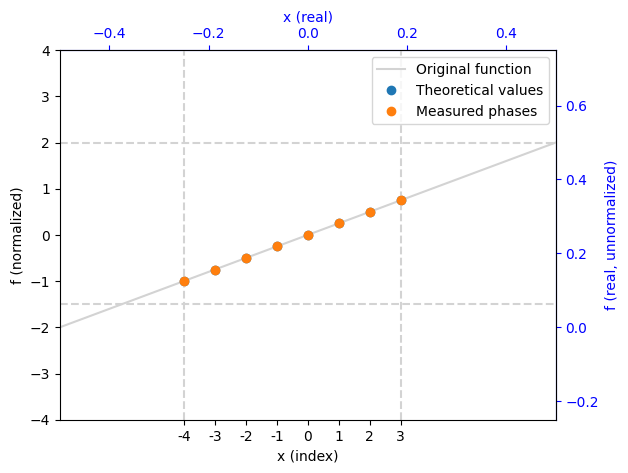

In [7]:
p = params()
# f(x) = 0.5*x + 0.25
# Gradient: f'(0) = 0.5
p.set_function(p.linear, (0.5, 0.25))
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))


df = run_statevector_simulation(main, print_circuit_info=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

The state is identical to the phase kickback method. Moving forward, we'll use the direct method for its superior efficiency.

### 2.1.3. Quadratic Function

Non-linear functions are more interesting. In the next example, we explore a quadratic function.

Note that the critical step occurs in the next phase when we apply the QFT. Here, the phases follow the function exactly without linearization. The QFT will extract the linear (gradient) component from these phase values.

Circuit Width: 3
Circuit Depth: 9
Gate Counts: {'u': 6, 'cx': 6}


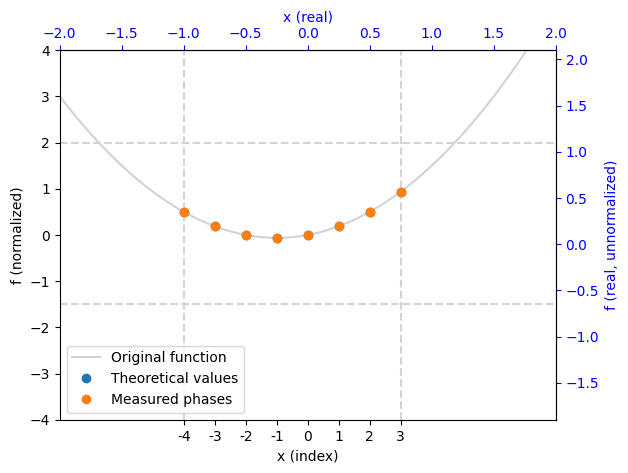

In [8]:
p = params()
# f(x) = 0.5*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.5, 0.25, 0.1))
p.l = 2
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))


df = run_statevector_simulation(main, print_circuit_info=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

Decreasing $l$ narrows the sampling interval, making the function appear more linear within that region.

Circuit Width: 3
Circuit Depth: 9
Gate Counts: {'u': 6, 'cx': 6}


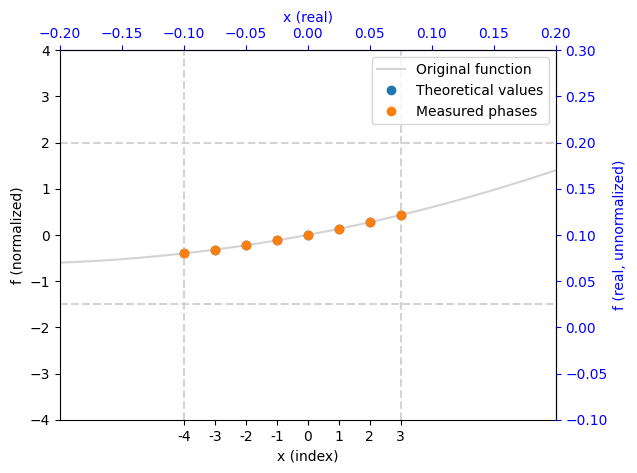

In [9]:
p = params()
# f(x) = 0.5*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.5, 0.25, 0.1))
p.l = 0.2
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))


df = run_statevector_simulation(main, print_circuit_info=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

## 2.2. Full Algorithm

### 2.2.1. Linear Functions

The final step is to apply the inverse QFT to the coordinates. This extracts the gradient from the phases and produces a measurable state containing the normalized gradient value.

Now we switch from statevector simulation to standard simulation, which measures the final result rather than examining phase values directly.

We start with a linear function.

Quantum program link: https://platform.classiq.io/circuit/3DIb1l6DjflPUfuyaOznk0sDwzs
Parsed counts: [{'x': -2}: 2048]
The analytical gradient is: -0.5
The majority gradient is: -0.5
The majority result is correct
####################################################
Success rate: 100.00% (2048/2048 shots)
[██████████████████████████████████████████████████] 100.00%


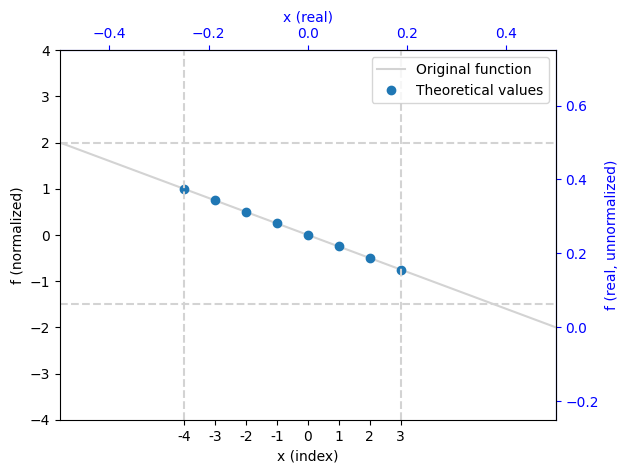

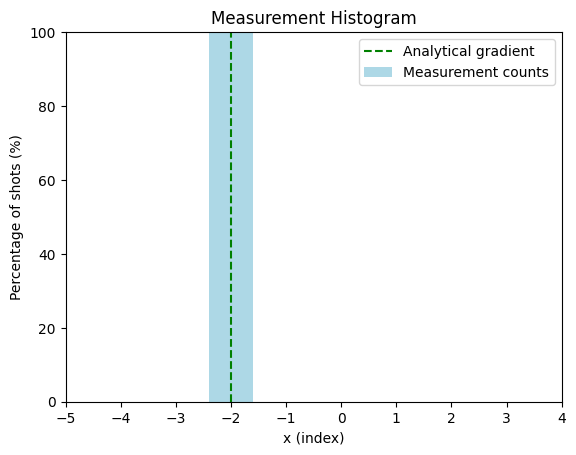

In [10]:
show_circuit = True  # Set to True to show the circuit

p = params()
p.set_function(p.linear, (-0.5, 0.25))
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))


qprog = synthesize(main)
if show_circuit:
    show(qprog)
job = execute(qprog)
# job.open_in_ide() # Uncomment to see the results in the IDE
pc = job.get_sample_result().parsed_counts
df = job.get_sample_result().dataframe

# You can use the helper function:
# pc, df = run_standard_simulation(main)

# Translate the majority state to a gradient value
majority_state = dict(df.iloc[0])
value = majority_state.get("x")
# Divide by (N/m) to get the actual gradient value.
majority_gradient = value / (N / m)
analytical_gradient = p.analytical_gradient(0)

# Or use the helper function:
# majority_gradient = state_to_gradient(majority_state.get('x'), p)

# Print the results and compute the majority gradient
print("Parsed counts:", pc)
print(f"The analytical gradient is: {analytical_gradient}")
print(f"The majority gradient is: {majority_gradient}")

# Check if the majority result is correct within the resolution of the algorithm
resolution = m / N
is_correct = abs(majority_gradient - analytical_gradient) < resolution / 2
print(f"The majority result is", "correct" if is_correct else "incorrect")
print("####################################################")

# Compute the success rate of the algorithm, i.e. the percentage of shots that are correct within the resolution of the algorithm.
success_rate, success_shots, total_shots = compute_success_rate(
    df, analytic_derivatives={"x": analytical_gradient}, p=p
)
print(f"Success rate: {success_rate:.2%} ({success_shots}/{total_shots} shots)")
show_bar(success_rate)

# Visualize the theoretical values of the phases
# We used the standard simulation, so this is theoretical values only without the phases from the simulation
plot_theoretical()

# Plot histogram of the results
plot_histogram(df, analytical_gradient=analytical_gradient)

# You can use the helper function:
# analyze_results(pc, df, p)

The measured gradient is always a multiple of the resolution $m/N$. In the previous example, the exact gradient -0.5 was a multiple of the resolution 0.25, so the success rate was 100%.

When the gradient is not a multiple of the resolution, the result becomes a superposition of nearby states. The algorithm still provides a good approximation, as shown in the next example.

Quantum program link: https://platform.classiq.io/circuit/3DIb2AIHYhra9keJamdJ86vntbo
Parsed counts: [{'x': 2}: 1781, {'x': 3}: 121, {'x': 1}: 67, {'x': -4}: 21, {'x': 0}: 16, {'x': -2}: 15, {'x': -1}: 15, {'x': -3}: 12]
The analytical gradient is: 0.55
The majority gradient is: 0.5
The majority result is correct
####################################################
Success rate: 86.96% (1781/2048 shots)
[███████████████████████████████████████████-------] 86.96%


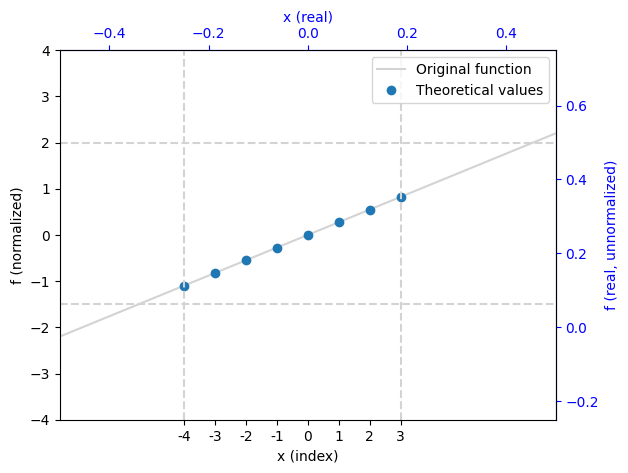

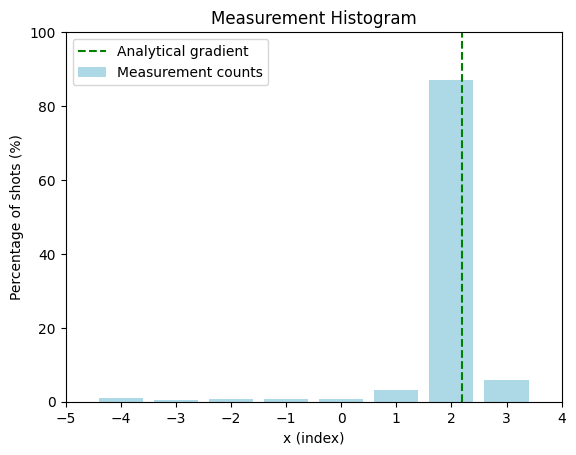

In [11]:
p = params()
# f(x) = 0.55*x + 0.25
# Gradient: f'(0) = 0.55
# Pay attention that 0.55 is not a multiple of m/N = 0.25,
# so we expect to get a superposition of multiple states around the correct gradient.
p.set_function(p.linear, (0.55, 0.25))
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))


pc, df = run_standard_simulation(main, show_circuit=True)
analyze_results(pc, df, p)

### 2.2.2. Quadratic Function

For non-linear functions, the interval $l$ must be chosen carefully. The algorithm requires the function to be approximately linear over the interval, which means $l$ must be sufficiently small. The next example demonstrates this dependency.

With appropriate selection of $l$, the function remains nearly linear over the sampling interval, yielding high success rates.

Parsed counts: [{'x': 1}: 2021, {'x': 0}: 14, {'x': 2}: 10, {'x': 3}: 2, {'x': -2}: 1]
The analytical gradient is: 0.25
The majority gradient is: 0.25
The majority result is correct
####################################################
Success rate: 98.68% (2021/2048 shots)
[█████████████████████████████████████████████████-] 98.68%


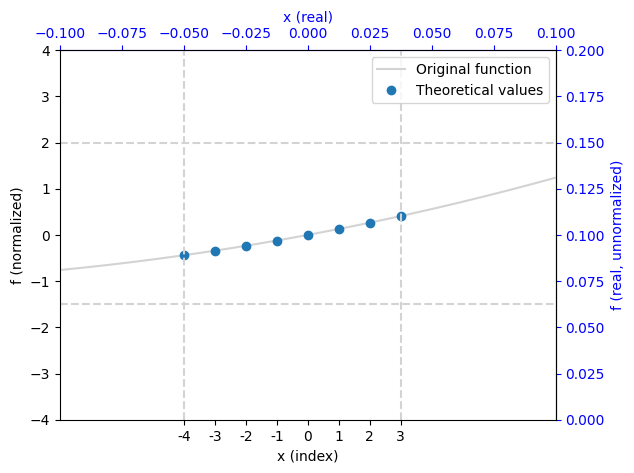

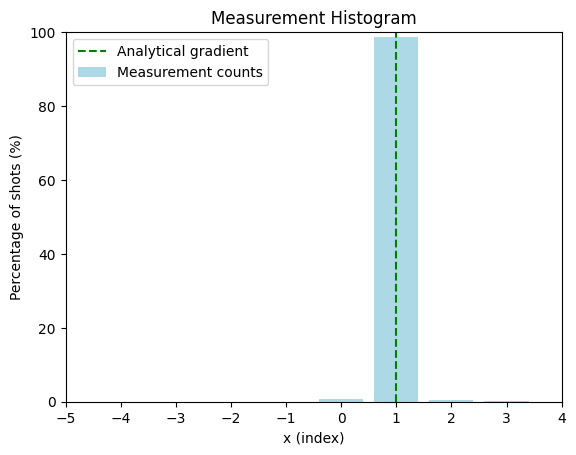

In [12]:
# In this example we will use the quadratic function
p = params()
# f(x) = 0.6*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = 1.2*x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.6, 0.25, 0.1))
# Setting l properly, ensuring we are in the linear regime of the function.
p.l = 0.1
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))


pc, df = run_standard_simulation(main)
analyze_results(pc, df, p)

Conversely, if $l$ is too large and the function deviates significantly from linearity, the success rate drops dramatically.

Parsed counts: [{'x': 2}: 497, {'x': 0}: 488, {'x': 1}: 486, {'x': -1}: 189, {'x': 3}: 188, {'x': -4}: 75, {'x': -2}: 65, {'x': -3}: 60]
The analytical gradient is: 0.25
The majority gradient is: 0.5
The majority result is incorrect
####################################################
Success rate: 23.73% (486/2048 shots)
[████████████--------------------------------------] 23.73%


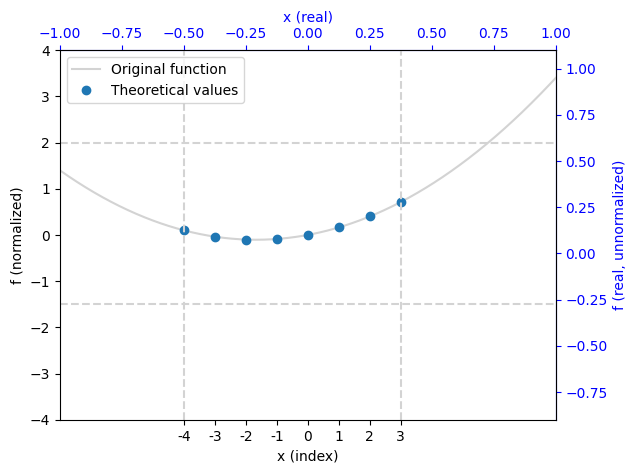

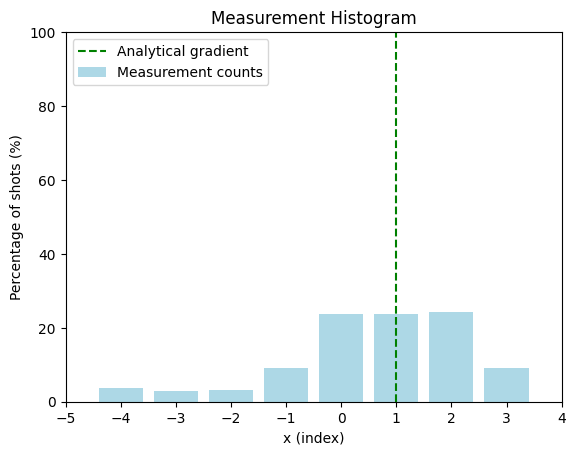

In [13]:
# In this example we will use the quadratic function
p = params()
# f(x) = 0.6*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = 1.2*x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.6, 0.25, 0.1))
# Setting l to be too big, so we are outside of the linear regime of the function.
p.l = 1
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))


pc, df = run_standard_simulation(main)
analyze_results(pc, df, p)

# 3. Performance Analysis

We can plot the success rate as a function of parameter choices. Consider a quadratic function $f(x)=0.6x^2+0.25x+0.1$ with $f'(0)=0.25$, and target accuracy $\epsilon=0.2$.

To determine valid parameter ranges, we need to use:
- $d=1$ (dimensionality)
- $D_2=1.2$ (second derivative bound)
- $\nabla f_{\max}$: With $l \approx 0.1$, we have $\nabla f \in [0.19, 0.31]$, so $\nabla f_{\max}=0.31$

From the theory, the parameters must satisfy (with $n=3$):
- $m\geq 2 \cdot 0.31 = 0.62$
- $m\leq 2 \cdot N \cdot \epsilon = 3.2$
- $l\leq 0.28$

In the next graph, we plot success rate versus $m$ with $l=0.1$. The valid range $[0.62, 3.2]$ is highlighted.

m=0.05: Success rate = 0.00%
m=0.1: Success rate = 0.00%
m=0.33: Success rate = 0.39%
m=0.5: Success rate = 9.57%
m=0.67: Success rate = 93.41%
m=1.0: Success rate = 99.27%
m=1.33: Success rate = 80.32%
m=1.67: Success rate = 94.58%
m=2.0: Success rate = 98.78%
m=2.33: Success rate = 90.97%
m=2.67: Success rate = 77.34%
m=3.0: Success rate = 64.70%
m=3.33: Success rate = 54.88%
m=3.67: Success rate = 0.00%
m=4.0: Success rate = 0.00%
m=6.0: Success rate = 0.00%
m=10.0: Success rate = 0.00%


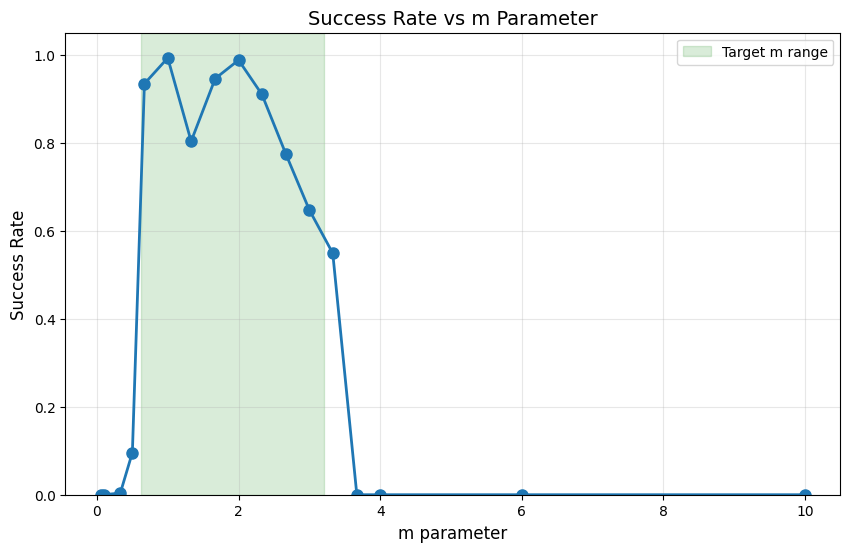

In [ ]:
def plot_success_rate_vs_m(m_values, function, function_params, l_val=0.1, n_val=3):
    """
    Iterate over different m values and plot success rate as a function of m.

    Args:
        m_values: list of m values to test
        function: function name ("linear" / "quadratic") or callable
        function_params: parameters for the function
        l_val: l parameter (default 0.1)
        n_val: n parameter (default 3)
    """
    success_rates = []

    for m_val in m_values:
        p = params()
        p.m = m_val
        p.l = l_val
        p.n = n_val
        p.set_function(function, function_params)
        p.unpack(globals())

        @qfunc
        def main(x: Output[QNum[n, SIGNED, 0]]):
            allocate(n, x)
            hadamard_transform(x)
            phase(f_normalized(x), 2 * pi)
            invert(lambda: qft(x))

        pc, df = run_standard_simulation(main)
        analytic_grad = p.analytical_gradient(0)
        epsilon = 0.2
        success_rate, _, _ = compute_success_rate(
            df,
            analytic_derivatives={"x": analytic_grad},
            p=p,
            tolerance=epsilon,
        )
        success_rates.append(success_rate)
        print(f"m={m_val}: Success rate = {success_rate:.2%}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(m_values, success_rates, "o-", linewidth=2, markersize=8)
    plt.xlabel("m parameter", fontsize=12)
    plt.ylabel("Success Rate", fontsize=12)
    plt.title("Success Rate vs m Parameter", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1.05])
    ax = plt.gca()
    theoretical_range = (0.62, 3.2)
    ax.axvspan(theoretical_range[0], theoretical_range[1], color="green", alpha=0.15)
    plt.show()
    return success_rates


# Example usage:
m_values = [
    0.05,
    0.1,
    0.33,
    0.5,
    0.67,
    1.0,
    1.33,
    1.67,
    2.0,
    2.33,
    2.67,
    3.0,
    3.33,
    3.67,
    4.0,
    6.0,
    10.0,
]
results = plot_success_rate_vs_m(m_values, "quadratic", (0.6, 0.25, 0.1))

Next, we plot success rate versus $l$ with $m=2$. The valid bound $l\leq 0.28$ is highlighted.

l=0.1: Success rate = 94.68%
l=0.2: Success rate = 78.03%
l=0.3: Success rate = 59.18%
l=0.4: Success rate = 38.82%
l=0.5: Success rate = 25.34%
l=1: Success rate = 10.06%
l=1.5: Success rate = 16.46%
l=2.0: Success rate = 12.26%
l=3.0: Success rate = 26.03%


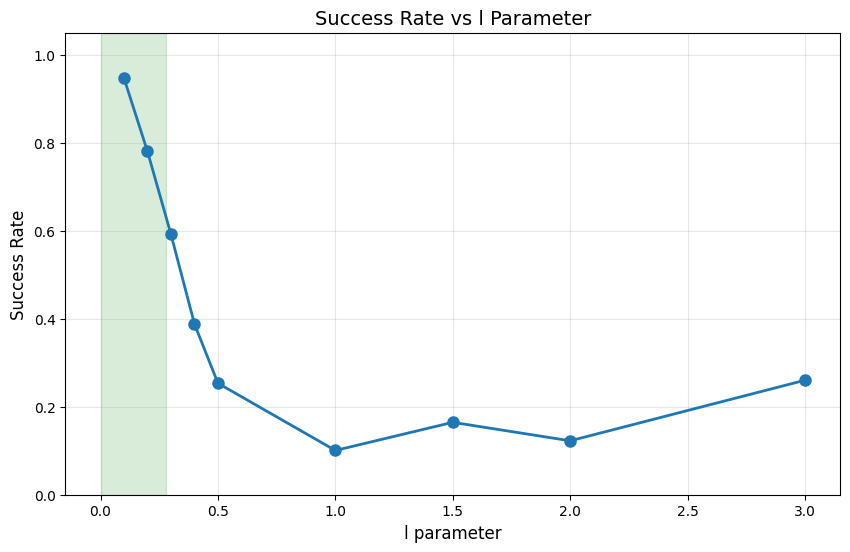

In [10]:
def plot_success_rate_vs_l(l_values, function, function_params, m_val=2.0, n_val=3):
    """
    Iterate over different l values and plot success rate as a function of l.

    Args:
        l_values: list of l values to test
        function: function name ("linear" / "quadratic") or callable
        function_params: parameters for the function
        m_val: m parameter (default 1.0)
        n_val: n parameter (default 3)
    """
    success_rates = []

    for l_curr in l_values:
        p = params()
        p.m = m_val
        p.l = l_curr
        p.n = n_val
        p.set_function(function, function_params)
        p.unpack(globals())

        @qfunc
        def main(x: Output[QNum[n, SIGNED, 0]]):
            allocate(n, x)
            hadamard_transform(x)
            phase(f_normalized(x), 2 * pi)
            invert(lambda: qft(x))

        pc, df = run_standard_simulation(main)
        analytic_grad = p.analytical_gradient(0)
        success_rate, _, _ = compute_success_rate(
            df, analytic_derivatives={"x": analytic_grad}, p=p
        )
        success_rates.append(success_rate)
        print(f"l={l_curr}: Success rate = {success_rate:.2%}")

    plt.figure(figsize=(10, 6))
    plt.plot(l_values, success_rates, "o-", linewidth=2, markersize=8)
    plt.xlabel("l parameter", fontsize=12)
    plt.ylabel("Success Rate", fontsize=12)
    plt.title("Success Rate vs l Parameter", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1.05])
    ax = plt.gca()
    theoretical_range = (0, 0.28)
    ax.axvspan(theoretical_range[0], theoretical_range[1], color="green", alpha=0.15)

    plt.show()

    return success_rates


# Example usage:
l_values = [0.1, 0.2, 0.3, 0.4, 0.5, 1, 1.5, 2.0, 3.0]
results_l = plot_success_rate_vs_l(
    l_values, "quadratic", (0.6, 0.25, 0.1), m_val=1.0, n_val=3
)

# 4. Multi-Dimensional Examples

The algorithm extends to multiple dimensions. We demonstrate with a 2D example using a linear, decoupled function $f(x,y)=ax+by+c$.

In [19]:
px = params()
py = params()

# Set the functions for x and y axes
# f(x, y) = a*x + b*y + c = 0.5*x - 0.25*y + 0.1
# df/dx = 0.5, df/dy = -0.25
a, b, c = 0.5, -0.25, 0.1
px.set_function(px.linear, (a, 0.0))
py.set_function(py.linear, (b, c))

# Important: we can't use the globals here, because there are two different functions for px and for py.


@qfunc
def main(x: Output[QNum[px.n, SIGNED, 0]], y: Output[QNum[py.n, SIGNED, 0]]):
    # State preparation for x-axis contribution
    allocate(px.n, x)
    hadamard_transform(x)
    phase(px.f_normalized(x), 2 * pi)

    # State preparation for y-axis contribution
    allocate(py.n, y)
    hadamard_transform(y)
    phase(py.f_normalized(y), 2 * pi)

    # Gradient extraction on each axis
    invert(lambda: qft(x))
    invert(lambda: qft(y))


pc, df = run_standard_simulation(main)
print(pc)

majority_state = dict(df.iloc[0])
gx_true = px.analytical_gradient(0)
gy_true = py.analytical_gradient(0)

gx_meas = (majority_state.get("x")) / (px.N / px.m)
gy_meas = (majority_state.get("y")) / (py.N / py.m)

print(f"Analytical gradient: (dx, dy) = ({gx_true}, {gy_true})")
print(f"Majority gradient:   (dx, dy) = ({gx_meas}, {gy_meas})")

success_rate, success_shots, total_shots = compute_success_rate(
    df, analytic_derivatives={"x": gx_true, "y": gy_true}, p=px
)
print(f"Success rate: {success_rate:.2%} ({success_shots}/{total_shots} shots)")
show_bar(success_rate)

[{'x': 2, 'y': -1}: 2048]
Analytical gradient: (dx, dy) = (0.5, -0.25)
Majority gradient:   (dx, dy) = (0.5, -0.25)
Success rate: 100.00% (2048/2048 shots)
[██████████████████████████████████████████████████] 100.00%


We can also demonstrate a more complex case with non-linear and coupled terms: $f(x, y)=ax^2+by^2+cxy+dx+ey+f$.

In [20]:
p = params()
p.l = 0.1
p.unpack(globals())


def f(x, y):
    a, b, c, d, e, f = 0.6, -0.4, 0.25, 0.25, -0.5, 0.1
    global gradient_x, gradient_y
    gradient_x = d
    gradient_y = e
    return a * x**2 + b * y**2 + c * x * y + d * x + e * y + f


# Generated functions
def f_normalized(x, y):
    val = f(l / N * x, l / N * y)
    val *= N / (l * m)
    return val


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]], y: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    # Build arrays in two's complement binary order for prepare_complex_amplitudes.
    # Binary index i maps to signed value: i if i < N//2 else i - N
    idx = np.arange(N)
    x_signed = np.where(idx < N // 2, idx, idx - N)
    y_signed = np.where(idx < N // 2, idx, idx - N)

    # In order to use the prepare_complex_amplitudes function, we need to flatten the 2D arrays of magnitudes and phases into 1D arrays.
    X_grid, Y_grid = np.meshgrid(x_signed, y_signed, indexing="ij")
    phases_2d = f_normalized(X_grid, Y_grid) * 2 * np.pi
    magnitudes_2d = np.ones((N, N)) / N
    phases_flat = phases_2d.flatten().tolist()
    magnitudes_flat = magnitudes_2d.flatten().tolist()

    # Prepare the state using the flattened arrays, then bind the combined register to the x and y registers.
    combined_reg = QNum("combined_reg")
    prepare_complex_amplitudes(
        magnitudes=magnitudes_flat, phases=phases_flat, out=combined_reg
    )
    bind(combined_reg, [y, x])

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    invert(lambda: qft(x))
    invert(lambda: qft(y))


pc, df = run_standard_simulation(main)
print(pc)

majority_state = dict(df.iloc[0])
gx_true = gradient_x
gy_true = gradient_y

gx_meas = state_to_gradient(majority_state.get("x"), p)
gy_meas = state_to_gradient(majority_state.get("y"), p)

print(f"Analytical gradient: (dx, dy) = ({gx_true}, {gy_true})")
print(f"Majority gradient:   (dx, dy) = ({gx_meas}, {gy_meas})")

success_rate, success_shots, total_shots = compute_success_rate(
    df, analytic_derivatives={"x": gx_true, "y": gy_true}, p=p
)
print(f"Success rate: {success_rate:.2%} ({success_shots}/{total_shots} shots)")
show_bar(success_rate)

[{'x': 1, 'y': -2}: 1993, {'x': 0, 'y': -2}: 18, {'x': 2, 'y': -2}: 9, {'x': 1, 'y': -1}: 8, {'x': 1, 'y': -3}: 4, {'x': -2, 'y': -2}: 4, {'x': 0, 'y': -1}: 3, {'x': 2, 'y': -1}: 2, {'x': 1, 'y': -4}: 1, {'x': -1, 'y': 3}: 1, {'x': 0, 'y': 3}: 1, {'x': 0, 'y': -4}: 1, {'x': -4, 'y': -2}: 1, {'x': 3, 'y': 3}: 1, {'x': -1, 'y': -2}: 1]
Analytical gradient: (dx, dy) = (0.25, -0.5)
Majority gradient:   (dx, dy) = (0.25, -0.5)
Success rate: 97.31% (1993/2048 shots)
[█████████████████████████████████████████████████-] 97.31%


# 5. Summary and Discussion

This notebook demonstrated Jordan's quantum gradient estimation algorithm, which estimates $\nabla f$ at the origin using a **single query** to $f$, compared to the classical lower bound of $d+1$ queries.

## Algorithm

1. Prepare a uniform superposition over $N = 2^n$ sample points using Hadamard gates.
2. Encode $f$ as phases, either via phase kickback from a state oracle or directly using a phase oracle.
3. Apply the inverse QFT to map the phase encoding onto a measurable computational basis state containing $\nabla f$.

## Parameter Selection

| Parameter | Role | Constraint |
|---|---|---|
| $l$ | Sampling interval | $l \leq \frac{2\sqrt{3}\epsilon}{D_2\sqrt{d}}$ — keeps $f$ approximately linear |
| $m$ | Gradient range | $2\nabla f_{\max} \leq m \leq 2N\epsilon$ |
| $n$ | Qubits / resolution | $n \geq \log_2(\nabla f_{\max} / \epsilon)$ |

## Potential Use Cases

The $d+1 \to 1$ query reduction is most valuable when $d$ is large and each function evaluation is expensive.

Potential applications include: Optimization, Root-finding, Functional minimization and PDEs and more.

## Limitation: Higher-Order Derivatives

The algorithm **cannot be applied recursively** to compute second or higher-order derivatives of $f$.

The method requires a quantum oracle that evaluates $f(x)$ coherently as a phase across all $x$ simultaneously. After running the circuit and measuring, the output is a single classical value $\nabla f(0)$ — not a new quantum oracle for $\nabla f(x)$ at arbitrary points $x$. Estimating $\nabla^2 f$ by this approach would require such an oracle for $\nabla f$, which the algorithm does not construct.

In classical finite differences, second derivatives are obtained by calling $f$ at multiple points and differencing the first-derivative estimates. Replicating this quantumly would require separate oracle queries for each evaluation point, reducing the query complexity back to the classical $O(d^2)$ regime and eliminating the quantum advantage entirely.

# Appendices
## Appendix 1 - Phase Kickback

We start with the state $|\delta\rangle|0\rangle$ where $|\delta\rangle$ is a superposition created by the Hadamard gate for all the coordinates, hence:
$$\sum_{\delta_1=0}^{N-1}\cdots\sum_{\delta_d=0}^{N-1}|\delta_1\rangle\cdots|\delta_d\rangle$$
For convenience we will look at the $d=1$ case, but the same procedure can be used for bigger $d$.

The ancilla starts at the ground state $|a\rangle=|0\rangle$.
We first apply bitwise X gate to create the state $|111\cdots1\rangle$, which in the signed fractional QNum representation corresponds to the value $-1/N_0$.

Next, we apply QFT on the ancilla. Using the fact that $e^{i2\pi a} = 1$ for integer $a$, the QFT of $|N_0-1\rangle$ simplifies to:
$$ \frac{1}{\sqrt{N_0}}\sum_{a=0}^{N_0-1}e^{i2\pi a(N_0-1)/N_0}|a\rangle = \frac{1}{\sqrt{N_0}}\sum_{a=0}^{N_0-1}e^{-i2\pi a/N_0}|a\rangle $$

The full state after both Hadamard (on coordinates) and QFT (on ancilla) is:
$$\frac{1}{\sqrt{N \cdot N_0}}\sum_{\delta=0}^{N-1}\sum_{a=0}^{N_0-1} e^{-i2\pi a/N_0}\,|\delta\rangle|a\rangle$$

As discussed before, we assume that we have an oracle $f$ that applies the function on the state $|x\rangle \rightarrow |f(x)\rangle$.
We apply this function and add the normalized result $f_\mathrm{norm}(\delta) = \frac{N}{ml}f\!\left(\frac{l}{N}\delta\right)$ to the ancilla register, mapping $|a\rangle \to |a + f_\mathrm{norm}(\delta)\rangle$:

$$\frac{1}{\sqrt{N \cdot N_0}}\sum_{\delta,\,a} e^{-i2\pi a/N_0}\,|\delta\rangle\,|a + f_\mathrm{norm}(\delta)\rangle$$

Substituting $a' = a + f_\mathrm{norm}(\delta)$, i.e. $a = a' - f_\mathrm{norm}(\delta)$:

$$\frac{1}{\sqrt{N \cdot N_0}}\sum_{\delta,\,a'} e^{-i2\pi (a' - f_\mathrm{norm}(\delta))/N_0}\,|\delta\rangle\,|a'\rangle$$

Separating the phase into two factors:

$$= \frac{1}{\sqrt{N}}\sum_{\delta=0}^{N-1} e^{i2\pi f_\mathrm{norm}(\delta)/N_0}\,|\delta\rangle \;\otimes\; \underbrace{\frac{1}{\sqrt{N_0}}\sum_{a'=0}^{N_0-1} e^{-i2\pi a'/N_0}\,|a'\rangle}_{\text{original ancilla state}}$$

The ancilla returns to its pre-oracle state and the function value has been "kicked back" as a phase onto the coordinate register.
Since the ancilla is a fractional QNum with $n_0$ fractional bits, dividing by $N_0$ converts from the integer index back to the fractional value, so $f_\mathrm{norm}(\delta)/N_0 \to f_\mathrm{norm}(\delta)$ in the fractional encoding.
The coordinate register is therefore left in the state:

$$\sum_{\delta=0}^{N-1} e^{i2\pi f_\mathrm{norm}(\delta)}\,|\delta\rangle = \sum_{\delta=0}^{N-1} e^{i2\pi \frac{N}{ml} f\!\left(\frac{l}{N}\delta\right)}\,|\delta\rangle$$

This is exactly the desired phase state from Step 2 of the algorithm, and the rest of the algorithm proceeds identically to the Direct Phase approach.


# References

<a id='original_paper'>[1]</a>: [Stephen P. Jordan. Fast Quantum Algorithm for Numerical Gradient Estimation. Physical Review Letters 95 (2005)](https://www.researchgate.net/publication/7669221_Fast_Quantum_Algorithm_for_Numerical_Gradient_Estimation)